In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit

FigureWidth = 3.375
factor = 2
# Set global parameters
params = {
          'lines.linewidth': 3,
          'axes.labelsize': int(11*factor),
          'legend.fontsize': int(6*factor),
          'xtick.labelsize': int(10*factor),
          'ytick.labelsize': int(10*factor),
          'text.usetex': True,
          'font.family': 'serif'}
plt.rcParams.update(params)
plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"

In [2]:
#Read data 
filename = 'all_data.dat'
data = pd.read_csv(filename, sep = ' ')
#convert to data frame
df= pd.DataFrame({'We': data["We"],'Ec':data["Ec"], 'El':data["El"], 'force_max':data["force_max"] })
#print(df)

In [3]:
#Datasets: We group the data for ease of analysis

#Sufficiently high We for Wagner scaling
df_highWe = df[df['We']>=20] 

#High El- Hertz
df_hertz = df[df['El']>=2]

#Low El- Wagner
df_wagner = df_highWe[df_highWe['El']<=0.1]

# With Weber corretion for Wagner's scaling
df_we_wagner = df[df['El']<=0.1]

[]

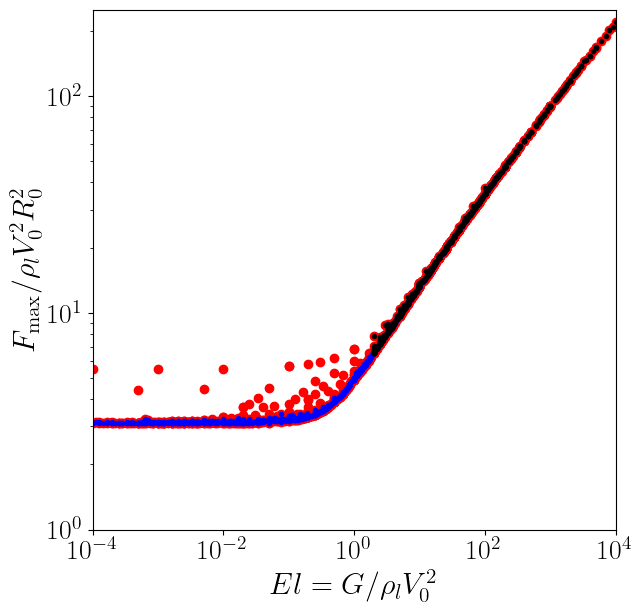

In [4]:
#Plot to check if data correctly classified
def prepare_plot(params):
    fig, ax = plt.subplots(figsize=(factor*FigureWidth, factor*FigureWidth))
    ax.set_xlim(params["Elmin"], params["Elmax"])
    ax.set_ylim(params["Vmin"], params["Vmax"])
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$El = G/\rho_l V_0^2$')
    ax.set_ylabel(r'$F_{\text{max}}/\rho_l V_0^2R_0^2$')
    ax.minorticks_on()
    
    return fig, ax

#plot initial data
plt_params = {
    "Elmin": 1e-4, "Elmax": 1e4,
    "Vmin": 1e0, "Vmax": 2.5e2
}

fig, ax = prepare_plot(plt_params)

plt.plot(df["El"], df["force_max"],'ro') 
plt.plot(df_highWe["El"], df_highWe["force_max"],'b.')
plt.plot(df_hertz["El"], df_hertz["force_max"],'k.')

plt.plot()


In [5]:
#defining functions

#A) Scaling laws
# 1) Hertz
def f_1(x):
    y = 5.3*(x**0.4)
    return y

# 2) Wagner's theory
def f_0(x):
    y = np.ones(len(x))
    y = 3.2*y
    return y

# 3) Wagner's theory with the capillary corrections
def f_01(x, We):
    y = np.ones(len(x))
    y = (3.24 + 3.2/We)*y
    return y


#B) Weighted Transition functions
# Tanh transition function
def tanh_tt(x, a, x0):
    y = 0.5 + ((1-np.exp(-2*a*(x-x0)))/(1+np.exp(-2*a*(x-x0))))/2
    return y

# Sigmoid funtion 
def sgm(x, a, x0):
    y = 1/(1+np.exp(-a*(x-x0)))
    return y

In [6]:
#Best weighted tanh transition fit 
def func3(x, a, x0):
    y = f_1(x)*tanh_tt(x, a, x0) +f_0(x)*(1-tanh_tt(x, a, x0))
    return y

popt3, pcov3 = curve_fit(func3, df_highWe["El"], df_highWe["force_max"])
print(popt3)

a = popt3[0] #obtaining the parameters
x0 = popt3[1]
print(1/a)

[4.6271712  0.41151496]
0.21611476137738717


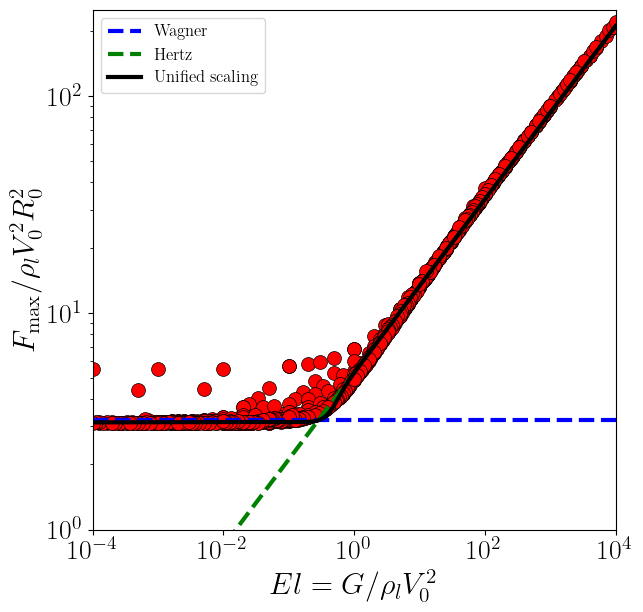

In [7]:
#plot Wagner to Hertz Transition obtained: use tanh fit

plt_params = {
    "Elmin": 1e-4, "Elmax": 1e4,
    "Vmin": 1e0, "Vmax": 2.5e2
}

x = np.logspace(-4,4, 1000 ) #between Wagner and Hertz
fig, ax = prepare_plot(plt_params)
#print(x)

#tanh fit
func = f_1(x)*tanh_tt(x, 4.54, 0.41) +f_0(x)*(1-tanh_tt(x, 4.54, 0.41))

plt.plot(df["El"], df["force_max"],'ro', markersize=10, markeredgewidth=0.5, linewidth=1.2, markeredgecolor='black')
#plt.plot(df_hertz["El"], df_hertz["force_max"],'k.')
#plt.plot(df_wagner["El"], df_wagner["force_max"],'b.')
plt.plot(x, f_0(x), 'b--', label='Wagner')
plt.plot(x, f_1(x), 'g--', label='Hertz')
plt.plot(x, func, 'k', label='Unified scaling')
plt.legend()

plt.show()

In [8]:
#For different We
# classify the lower We cases separately

df_We_1 = df[df['We'] == 1]#We = 1
df_We_2 = df[df['We'] == 2]#We=2
df_We_4 = df[df['We'] == 4]#We=4
df_We_10 = df[df['We'] == 10]#We=10


In [9]:
#tanh fit for different We- obtain the values of parameters for the tanh transition
## We = 1
def func_we_1(x, a, x0):
    y = f_1(x)*tanh_tt(x, a, x0) +f_01(x, 1)*(1-tanh_tt(x, a, x0))
    return y

popt_we1, pcov_we1 = curve_fit(func_we_1, df_We_1["El"], df_We_1["force_max"])
a_1 = popt_we1[0]
x0_1 = popt_we1[1]
print(a_1, x0_1)

## We = 2
def func_we_2(x, a, x0):
    y = f_1(x)*tanh_tt(x, a, x0) +f_01(x, 2)*(1-tanh_tt(x, a, x0))
    return y

popt_we2, pcov_we2 = curve_fit(func_we_2, df_We_2["El"], df_We_2["force_max"])
a_2 = popt_we2[0]
x0_2 = popt_we2[1]
print(a_2, x0_2)

## We = 4
def func_we_4(x, a, x0):
    y = f_1(x)*tanh_tt(x, a, x0) +f_01(x, 4)*(1-tanh_tt(x, a, x0))
    return y

popt_we4, pcov_we4 = curve_fit(func_we_4, df_We_4["El"], df_We_4["force_max"])
a_4 = popt_we4[0]
x0_4 = popt_we4[1]
print(a_4, x0_4)

## We = 10
def func_we_10(x, a, x0):
    y = f_1(x)*tanh_tt(x, a, x0) +f_01(x, 10)*(1-tanh_tt(x, a, x0))
    return y

popt_we10, pcov_we10 = curve_fit(func_we_10, df_We_10["El"], df_We_10["force_max"])
a_10 = popt_we10[0]
x0_10 = popt_we10[1]
print(a_10, x0_10)

0.7236844364117961 1.3080548771993588
2.016990846193106 0.7182415524418875
8.428621824178427 0.7552371856208978
3.9788685101409222 0.3894007602197875


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


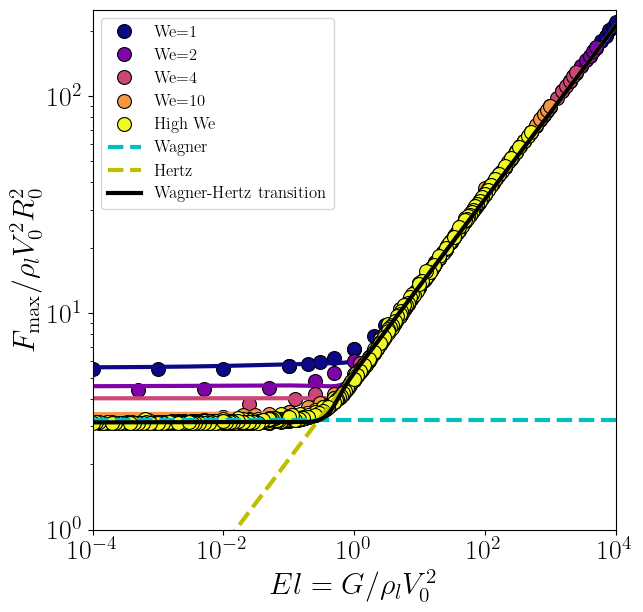

In [10]:
# Plot the obtained transitions with parameters obtained from the data.
plt_params = {
    "Elmin": 1e-4, "Elmax": 1e4,
    "Vmin": 1e0, "Vmax": 2.5e2
}
# Define colors
We = [1, 2, 4, 10, 100]
COLORNUM = colors = plt.cm.plasma(np.linspace(0, 1, len(We)))
x = np.logspace(-4,4, 1000 ) #between Wagner and Hertz
fig, ax = prepare_plot(plt_params)
#tanh fit
func_we1 = f_1(x)*tanh_tt(x, a_1, x0_1) +f_01(x,1)*(1-tanh_tt(x, a_1, x0_1))
func_we2 = f_1(x)*tanh_tt(x, a_2, x0_2) +f_01(x,2)*(1-tanh_tt(x, a_2, x0_2))
func_we4 = f_1(x)*tanh_tt(x, a_4, x0_4) +f_01(x,4)*(1-tanh_tt(x, a_4, x0_4))
func_we10 = f_1(x)*tanh_tt(x, a_10, x0_10) +f_01(x,10)*(1-tanh_tt(x, a_10, x0_10))

plt.plot(df_We_1["El"], df_We_1["force_max"], "o", color=COLORNUM[0], markersize=10, markeredgewidth=0.8, markeredgecolor='black', label = r'We=1')
plt.plot(x, func_we1, color=COLORNUM[0], linewidth=3)

plt.plot(df_We_2["El"], df_We_2["force_max"], "o", color=COLORNUM[1],markersize=10, markeredgewidth=0.8, markeredgecolor='black', label = r'We=2')
plt.plot(x, func_we2, color=COLORNUM[1], linewidth=3)

plt.plot(df_We_4["El"], df_We_4["force_max"], "o", color=COLORNUM[2], markersize=10, markeredgewidth=0.8, markeredgecolor='black', label = r'We=4')
plt.plot(x, func_we4, color=COLORNUM[2], linewidth=3)

plt.plot(df_We_10["El"], df_We_10["force_max"], "o", color=COLORNUM[3], markersize=10, markeredgewidth=0.8, markeredgecolor='black', label = r'We=10')
plt.plot(x, func_we10, color=COLORNUM[3], linewidth=3)

plt.plot(df_highWe["El"], df_highWe["force_max"],'o', color=COLORNUM[4],  markersize=10, markeredgewidth=0.8, markeredgecolor='black', label = r'High We')

#plot the scalinf laws fpr comparison
plt.plot(x, f_0(x), 'c--', label = r'Wagner')
plt.plot(x, f_1(x), 'y--', label = r'Hertz')
plt.plot(x, func, 'k', label = r'Wagner-Hertz transition')


plt.legend(loc='best')
plt.show()